# Timing methods

This notebook demonstrates some of the "quick-look" timing analyses available in `opticam`, as well as how to extend the available timing analyses using [`stingray`](https://docs.stingray.science/en/stable/).

## Generating and Reducing Data

Before we can explore the different timing analyses provided in `opticam`, we need some light curves to analyse. For this example, I'll generate and reduce some gappy observations (see the [reduction tutorial](reduction.ipynb) for more details on data reduction):

In [1]:
from pathlib import Path

import opticam


out_dir = Path('out')

opticam.generate_gappy_observations(
    out_directory=out_dir / 'data',
    n_images=500,  # generate lots of observations to create long light curves
    binning_scale=8,  # use large binning scale to reduce disk space
    circular_aperture=False,  # disable circular aperture shadow for simplicity
)

reducer = opticam.Reducer(
    data_directory=out_dir / 'data',
    out_directory=out_dir / 'reduced',
    show_plots=False,
    verbose=False,
    )
reducer.create_catalogs()

phot = opticam.OptimalPhotometer()
reducer.photometry(phot)

dphot = opticam.DifferentialPhotometer(
    out_directory=out_dir / 'reduced',
    show_plots=False,
)
analyser = dphot.get_relative_light_curve(
    fltr='g',
    target=2,
    comparisons=1,
    phot_label='optimal',
    prefix='source_2',  # name of target source
    match_other_cameras=True,
    show_diagnostics=False,
)

[OPTICAM] variable source is at (65, 57)
[OPTICAM] variability RMS: 0.02 %
[OPTICAM] variability frequency: 0.135 Hz
[OPTICAM] variability phase lags:
    [OPTICAM] g-band: 0.000 radians
    [OPTICAM] r-band: 1.571 radians
    [OPTICAM] i-band: 3.142 radians


Generating observations:   0%|                                                                                                                                                                                                                                        |[00:00<?]

Generating observations:   0%|▉                                                                                                                                                                                                                                   |[00:00<00:32]

Generating observations:   1%|█▊                                                                                                                                                                                                                                  |[00:00<00:31]

Generating observations:   1%|██▋                                                                                                                                                                                                                                 |[00:00<00:31]

...

/home/zac/Documents/University/PhD/Repos/opticam/opticam/utils/data_checks.py:218: UserWarning: [OPTICAM] Large time gap detected between 240101g200000483o.fits.gz and 240101i200000482o.fits.gz (48.995 s compared to the median time difference of 1.000 s). This may cause alignment issues. If so, consider moving all files after this gap to a separate directory.
  warnings.warn(string)
/home/zac/Documents/University/PhD/Repos/opticam/opticam/utils/data_checks.py:218: UserWarning: [OPTICAM] Large time gap detected between 240101g200000448o.fits.gz and 240101i200000447o.fits.gz (19.998 s compared to the median time difference of 1.000 s). This may cause alignment issues. If so, consider moving all files after this gap to a separate directory.
  warnings.warn(string)
/home/zac/Documents/University/PhD/Repos/opticam/opticam/utils/data_checks.py:218: UserWarning: [OPTICAM] Large time gap detected between 240101g200000419o.fits.gz and 240101i200000418o.fits.gz (58.994 s compared to the median t

[OPTICAM] DarkNoiseCorrector sucessfully passed all checks.


[OPTICAM] Photometry results will be saved to lcs/optimal in out/reduced.


[OPTICAM] Filters: g, r, i


[OPTICAM] g target ID 2 was matched to r target ID 2
[OPTICAM] r comparison ID 1 was matched to r comparison ID 1
[OPTICAM] g target ID 2 was matched to i target ID 2
[OPTICAM] i comparison ID 1 was matched to i comparison ID 1


We now have an `Analyzer` instance that provides a number of quick-look timing analyses routines. Under-the-hood, these routines mostly `astropy` routines.

### `opticam.Analyzer` routines

Let's first take a look at our `Analyzer` light curves using the `plot()` method:

In [2]:
analyser.plot()

[OPTICAM] Plot saved to out/reduced/plots/source_2_optimal_light_curves.pdf.


As we can see, we have three variable, gappy light curves. The filter for each light curve is shown in the top right. We can also see that this figure was saved to `timing_analysis_tutorial/reduced/plots/source_2_optimal_light_curves.pdf`.

We can inspect our light curve data via the `light_curves` attribute. Within an `Analyzer`, light curves are stored as [`astropy.timeseries.TimeSeries`](https://docs.astropy.org/en/stable/timeseries/index.html) instances:

In [3]:
analyser.light_curves.pprint_all()

       time            g_rel_flux        g_rel_flux_err        r_rel_flux        r_rel_flux_err        i_rel_flux        i_rel_flux_err   
------------------ ------------------ -------------------- ------------------ -------------------- ------------------ --------------------
60309.999802757935  1.005223166710537 0.018049484855718344 1.0342238240271517  0.01840579688901044 1.0054633114804765 0.018053781758420755
 60309.99981433087 1.0498305410805062 0.018537282024778313 1.0475272635880328 0.018510840881674845 1.0069182801700876  0.01801955262060396
  60309.9998259038  0.994954663791711 0.017617379597568563 0.9642583379849766  0.01724774199833741 0.9405639546528622  0.01696111565591557
 60309.99983747672 1.0037347424438734 0.017733627848821026 0.9649383171417981  0.01726725857777787 0.9723741958647776  0.01735700481506178
 60309.99984904965 0.9925015837411737  0.01779642507877491 0.9723699276609359 0.017552671245672745  1.006813893020137   0.0179718985277651
 60309.99986062257  0.99150

Let's now perform a few quick-look timing analyses on these light curves.

### Lomb-Scargle Periodograms

Often times, you might want to compute the Lomb-Scargle periodograms of your light curves to check for periododic signals. `astropy` implements two flavours of the Lomb-Scargle periodogram: [`LombScargle`](https://docs.astropy.org/en/stable/timeseries/lombscargle.html) and [`LombScargleMultiband`](https://docs.astropy.org/en/stable/timeseries/lombscarglemb.html). For convenience, `opticam`'s `Analyzer` class implements wrappers for both routines that handle the boilerplate, allowing you to get straight to the analysis.

#### Lomb-Scargle

Let's first take a look at the standard Lomb-Scargle periodogram:

In [4]:
lsps = analyser.lomb_scargle()

[OPTICAM] Plot saved to out/reduced/plots/source_2_LSP.pdf.


We can see that each light curve has a dedicated periodogram, and the corresponding filter is shown in the top right of each panel. In this case, all three periodograms show a sharp peak between 0.1 and 0.2 Hz.

By default, the `autofrequency()` method of `astropy`'s `LombScargle` class is used to construct the frequency grid of the periodogram. Alternatively, you may pass your own frequency grid. To avoid confusion with units, custom frequency grids must be passed as an `astropy` [`Quantity`](https://docs.astropy.org/en/stable/units/quantity.html). For example, let's recompute these periodograms in the 0.1-0.2 Hz frequency range. However, we do not want to overwrite our previous plot, so we'll also pass `save=False` to prevent the new plot from being saved:

In [5]:
from astropy import units as u
import numpy as np

frequency = np.linspace(0.1, 0.2, 100) * u.Hz  # units of Hz

lsps = analyser.lomb_scargle(frequency=frequency, save=False)

Now we can see that all three bands suggest a signal with a frequency of between 0.12 and 0.14 Hz.

Like many of the timing analysis methods of `Analyzer`, `lomb_scargle()` returns a dictionary of results that may be used to conduct further analyses. In this case, the keys list the filters and the values list the corresponding [`astropy.timeseries.LombScargle`](https://docs.astropy.org/en/stable/api/astropy.timeseries.LombScargle.html#astropy.timeseries.LombScargle.from_timeseries) instances: 

In [6]:
lsps

{'g': <astropy.timeseries.periodograms.lombscargle.core.LombScargle at 0x74f873d8c050>,
 'r': <astropy.timeseries.periodograms.lombscargle.core.LombScargle at 0x74f873d8c180>,
 'i': <astropy.timeseries.periodograms.lombscargle.core.LombScargle at 0x74f8741f32f0>}

Let's use the results returned by the `lomb_scargle()` method to precisely infer the peak frequencies:

In [7]:
import numpy as np

for fltr, lsp in lsps.items():
    power = lsp.power(frequency=frequency)
    peak_index = np.argmax(power)
    print(f'{fltr} Peak frequency = {frequency[peak_index]}')

g Peak frequency = 0.13535353535353536 Hz
r Peak frequency = 0.13535353535353536 Hz
i Peak frequency = 0.13535353535353536 Hz


Now we can see that all three bands show a periodicity at $\sim$ 0.135 Hz which, as we can see at the top of this notebook, is the true frequency of variability for our source of interest.

#### Multiband Lomb-Scargle

In some cases, it may be preferable to compute a single Lomb-Scargle periodogram for all light curves; this can be done using `astropy`'s [`LombScargleMultiband`](https://docs.astropy.org/en/stable/timeseries/lombscarglemb.html):

In [8]:
periodograms = analyser.multiband_lomb_scargle()

[OPTICAM] Plot saved to out/reduced/plots/source_2_multiband_LSP.pdf.


As with `lomb_scargle()`, custom frequency grids can also be passed to `multiband_lomb_scargle()`:

In [9]:
periodograms = analyser.multiband_lomb_scargle(frequency=frequency, save=False)

### Phase Folding

Now that we have identified a candidate signal, we may want fold our light curves to see what it looks like. `astropy`'s `TimeSeries` class implements a `fold()` method, and `opticam`'s `Analyzer` class provides a convenience wrapper for this method. To fold a light curve, we need a period on which to fold; to avoid confusion with units, `opticam` requires that the period being passed is a `Quantity`:

In [10]:
f_signal = 0.135 * u.Hz  # periodogram peak frequency
p_signal = (1 / f_signal).to(u.s)  # fold period in seconds

folded_lcs = analyser.fold(
    period=p_signal,
)

[OPTICAM] Plot saved to out/reduced/plots/source_2_folded_P=7.4074074074074066 s.pdf.


The `fold()` method of `opticam.Analyzer` returns a `TimeSeries` whose `"time"` column quantifies the folded phase:

In [11]:
folded_lcs.pprint_all()

        phase              g_rel_flux        g_rel_flux_err        r_rel_flux        r_rel_flux_err        i_rel_flux        i_rel_flux_err   
                                                                                                                                              
---------------------- ------------------ -------------------- ------------------ -------------------- ------------------ --------------------
  -0.49985981220396775 1.0084651144001064   0.0180393920957993 1.0362915071854464 0.018378486418451193 1.0069161146175118  0.01802196150699383
  -0.49718195758777584 0.9811767231422861  0.01759308684097147  1.008729142199336 0.017931786885946616  0.979639326684942 0.017575578214714924
  -0.49436433950922115 0.9876757855816458 0.017598310578871602  1.014147152526647 0.017920127469031124  0.983863960712449  0.01755302456280664
   -0.4916866546265685    0.9879181537652  0.01736891430176468  1.013905525716661 0.017680497544618763 0.9846963485612149 0.017331740226355953

From the fold plot, it's clear that there is a lag in the pulsations between the different bands. Currently, `opticam` does not support quantify lags natively. However, `opticam`'s `Analyzer` class can be used to export your light curves to [`stingray`](https://docs.stingray.science/en/stable/), which provides a much more complete timing analysis framework. Let's take a look at this now.

## `stingray`

`stingray` is a feature-rich spectral timing Python package developed primarily for use with X-ray data. `stingray` implements a number of generic timing analyis routines that can be applied to arbitrary time series. However, since `stingray` was developed with X-ray data in mind, it makes certain assumptions about the data. These assumptions can cause issues for non-X-ray data, as we'll see soon.

To export your light curves to `stingray`, call the `export_light_curves_to_stingray()` method of `opticam.Analyzer`:

In [12]:
stingray_lcs = analyser.export_light_curves_to_stingray()

/home/zac/miniforge3/envs/opticam6/lib/python3.14/site-packages/stingray/utils.py:487: UserWarning: SIMON says: Stingray only uses poisson err_dist at the moment. All analysis in the light curve will assume Poisson errors. Sorry for the inconvenience.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)


We can see that a warning about error distributions has been triggered. We'll take a look at this in more detail later. For now, let's ignore it.

`export_light_curves_to_stingray()` returns a dictionary of {filter: [`stingray.Lightcurve`](https://docs.stingray.science/en/stable/notebooks/Lightcurve/Lightcurve%20tutorial.html)} pairs:

In [13]:
stingray_lcs

{'g': <stingray.lightcurve.Lightcurve at 0x74f873559810>,
 'r': <stingray.lightcurve.Lightcurve at 0x74f87355bed0>,
 'i': <stingray.lightcurve.Lightcurve at 0x74f87351df90>}

Let's take a closer look at one of these light curves using the `plot()` method of `stingray.Lightcurve`:

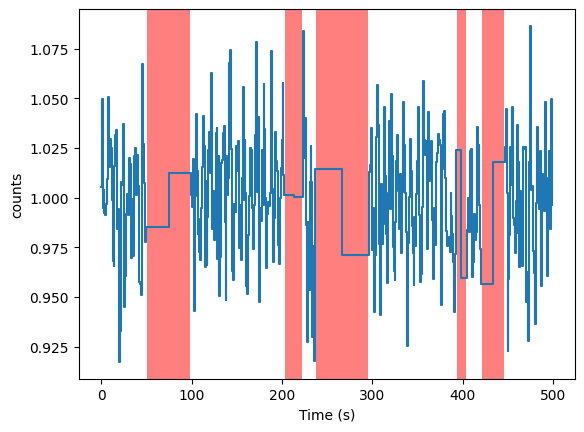

In [14]:
ax = stingray_lcs['g'].plot()

As we can see, the light curve times are converted into seconds, with $t=0$ corresponding to the `t_ref` attribute of the `Analyzer` instance. Additionally, `opticam` has automatically inferred GTIs for each light curve, which are required for compatibility with many of `stingray`'s methods. The shaded regions in the above plot represent the time between GTIs. Let's use these `stingray.Lightcurve` instances to do some more advanced analyses.

### Lags

#### Cross-correlation

Having recognised a lag between our light curves, there are several ways we can quantify it. For example, we can use the cross-correlations between light curves. This is a relatively simple approach, but it has the benefit of working with arbitrary time series. We can compute cross-correlations in `stingray` using [`CrossCorrelation`](https://docs.stingray.science/en/stable/notebooks/CrossCorrelation/cross_correlation_notebook.html):

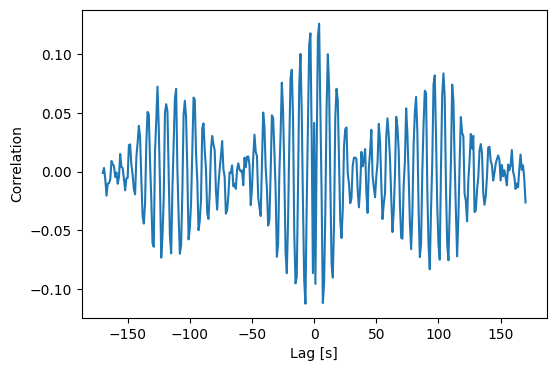

In [15]:
from stingray.crosscorrelation import CrossCorrelation

cross_corr = CrossCorrelation(
    lc1=stingray_lcs['g'],
    lc2=stingray_lcs['i'],
    )

ax = cross_corr.plot(
    labels=['Lag [s]', 'Correlation'],
    )

We can see that the cross-correlation spectrum peaks at a non-zero lag. We can get the exact time lag from the `time_shift` attribute of the `CrossCorrelation` instance:

In [16]:
print(f'g leads i by {cross_corr.time_shift}s')

g leads i by 3.999603632837534s


When we generated this data, we were told that the $i$-band variability has a phase lag of 3.142 (i.e., $1 \pi$) radians, while the $g$-band variability has a phase lag of 0 radians. We can convert this time lag into a phase lag by dividing it by the period of the variability:

In [17]:
print(f'Phase lag: {2 * np.pi * cross_corr.time_shift / p_signal.to_value(u.s)} radians')

Phase lag: 3.3925838553522305 radians


The phase lag is a little higher than expected, but this is due to the time resolution of our light curves.

Cross-correlating works well provided the light curves are dominated by the signal of interest. In many cases, however, light curves show variability on many time-scales, and we may want to isolate the lags of signals at specific frequencies. In such cases, it may be preferable to compute the cross-spectrum.

#### Cross-spectra

##### A Cautionary Tale

To compute cross-spectra, we can use `stingray`'s `AveragedCrossspectrum` class:

0it [00:00, ?it/s]

8it [00:00, 17137.09it/s]


/home/zac/miniforge3/envs/opticam6/lib/python3.14/site-packages/stingray/fourier.py:1134: UserWarning: n_ave is below 30. Please note that the error bars on the quantities derived from the cross spectrum are only reliable for a large number of averaged powers.
  warnings.warn(
/home/zac/miniforge3/envs/opticam6/lib/python3.14/site-packages/stingray/fourier.py:1161: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))


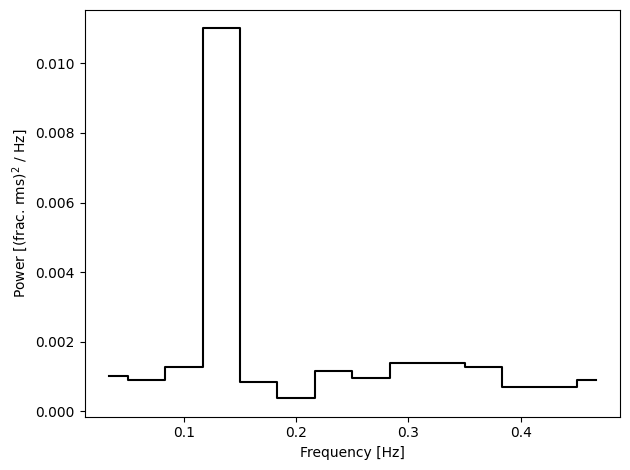

In [18]:
from stingray import AveragedCrossspectrum
from matplotlib import pyplot as plt

segment_size = 30 * u.s

avg_cs = AveragedCrossspectrum.from_lightcurve(
    lc1=stingray_lcs['g'],
    lc2=stingray_lcs['i'],
    norm='frac',
    segment_size=segment_size.to_value(u.s),  # stingray assumes all time values are in seconds
)

avg_cs_amplitude = np.abs(avg_cs.power)

fig, ax = plt.subplots(tight_layout=True)

ax.step(
    avg_cs.freq,  # convert freq from cyc/d to Hz
    avg_cs_amplitude,
    where='mid',
    c='k',
)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Power [(frac. rms)$^2$ / Hz]')

plt.show()

As we can see, the cross spectrum amplitude looks similar to the Lomb-Scargle periodograms we saw earlier, which is what we would expect. So far so good. Let's try to compute the coherence between these two light curves and check it's in the expected range ($0 \leq \text{coherence} \leq 1$):

In [19]:
coh, coh_err = avg_cs.coherence()

print(np.logical_and(coh >= 0, coh <= 1).all())

False


/home/zac/miniforge3/envs/opticam6/lib/python3.14/site-packages/stingray/utils.py:487: UserWarning: SIMON says: Number of segments used in averaging is significantly low. The result might not follow the expected statistical distributions.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)


Uh oh, we have unphysical coherence values! Let's take a look at some of them:

In [20]:
for i in range(5):
    print(f'Coherence: {coh[i]}, error: {coh_err[i]}')

Coherence: 125255.43870084993, error: -22164677.960628927
Coherence: 155590.86632007017, error: -30686217.678394
Coherence: 75731.82468126377, error: -10420340.272177516
Coherence: 849.3315903170263, error: -12361.588510501326
Coherence: 157376.1830838678, error: -31215892.516184118


Our coherence estimates are in the thousands, and our error estimates in the *negative thousands*. Something is very wrong...

The issue is due to `stingray` assuming Poisson statistics. Since we know the phase lag between these two light curves, let's see what happens if we try to compute it from the averaged cross spectrum:

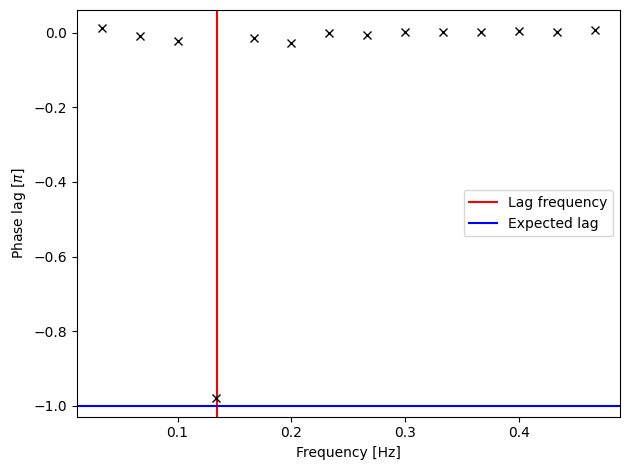

In [21]:
plags, plags_err = avg_cs.phase_lag()

fig, ax = plt.subplots(tight_layout=True)

ax.errorbar(
    avg_cs.freq,
    plags / np.pi,
    plags_err / np.pi,
    fmt='kx',
)

ax.axvline(
    0.135,
    c='red',
    label='Lag frequency'
    )
ax.axhline(
    -1,
    c='blue',
    label='Expected lag'
    )
ax.legend()

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Phase lag [$\\pi$]')

plt.show()

We get the correct phase lag at the correct frequency. However, we don't seem to have any error bars, and so it's impossible to quantify the significance of this lag. Let's see what our error bars are:

In [22]:
print(plags_err)

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan]


Our errors are all `NaN`s! This is another consequence of our light curves not having Poisson errors.

##### A Hacky Fix

To work around `stingray`'s requirement for Poisson errors, we can trick it into thinking our relative light curves are actually in units of counts by scaling them by a suitably large value (e.g., 10,000).

In [23]:
from stingray import Lightcurve

scale_factor = 1e4

lc = stingray_lcs['g']
f = lc.counts * scale_factor
err = lc.counts_err * scale_factor
g_lc = Lightcurve(lc.time, counts=f, err=err, gti=lc.gti)  # do not pass errors or define err_dist

lc = stingray_lcs['i']
f = lc.counts * scale_factor
err = lc.counts_err * scale_factor
r_lc = Lightcurve(lc.time, f, err=err, gti=lc.gti)  # do not pass errors or define err_dist

avg_cs = AveragedCrossspectrum.from_lightcurve(
    g_lc,
    r_lc,
    segment_size=segment_size.to_value(u.s),  # segment size in seconds
    norm='frac',
    )

0it [00:00, ?it/s]

8it [00:00, 23848.21it/s]

The fractional RMS normalisation (`norm='frac'`) is scale-invariant, so it should give us the same relative amplitudes. Let's now try to compute the averaged cross spectrum, coherence, and phase lags using our scaled light curves:

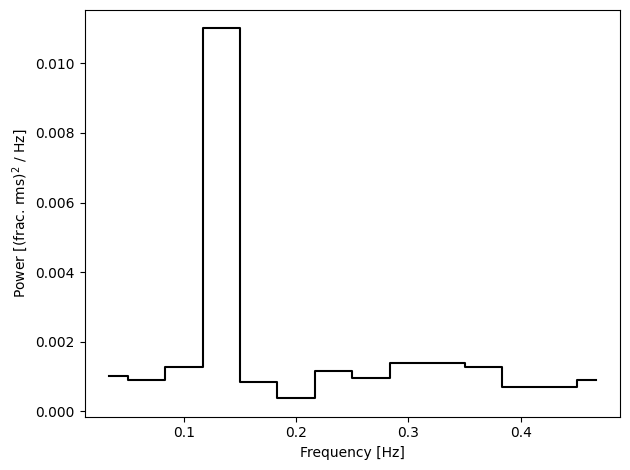

In [24]:
fig, ax = plt.subplots(tight_layout=True)

ax.step(
    avg_cs.freq,
    avg_cs_amplitude,
    where='mid',
    c='k',
)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Power [(frac. rms)$^2$ / Hz]')

plt.show()

Reassuringly, the averaged cross spectrum looks the same as before. Let's see if we can compute the coherence this time:

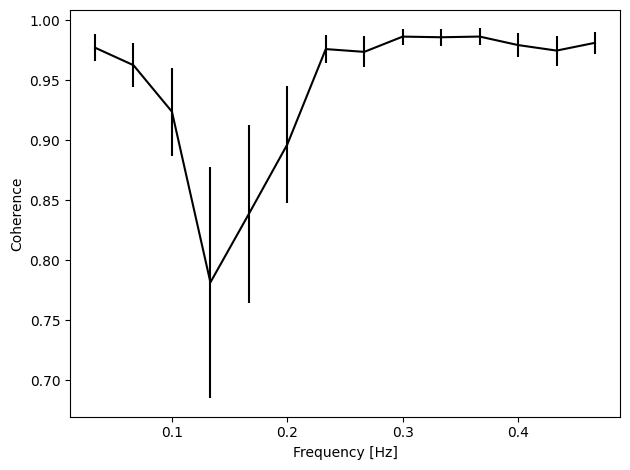

In [25]:
fig, ax = plt.subplots(tight_layout=True)

coh, coh_err = avg_cs.coherence()

ax.errorbar(
    avg_cs.freq,
    coh,
    coh_err,
    c='black',
)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Coherence')

plt.show()

We have a coherence plot with all values in the physical range 0 $\leq$ coherence $\leq$ 1!

Let's see how the phase lags look now:

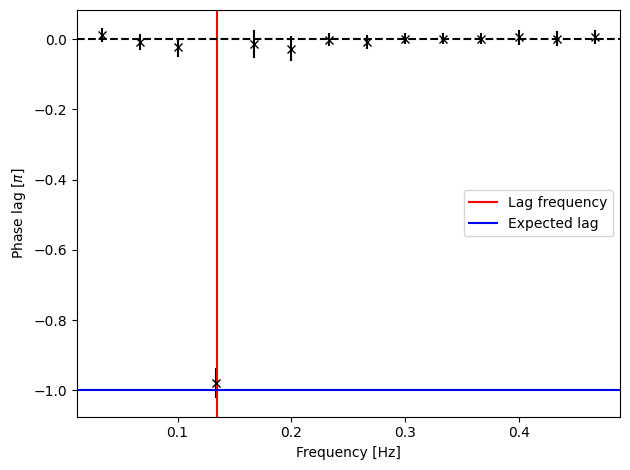

In [26]:
plags, plags_err = avg_cs.phase_lag()

fig, ax = plt.subplots(tight_layout=True)

ax.errorbar(
    avg_cs.freq,
    plags / np.pi,
    plags_err / np.pi,
    fmt='kx',
)

ax.axvline(
    0.135,
    c='red',
    label='Lag frequency'
    )
ax.axhline(
    -1,
    c='blue',
    label='Expected lag'
    )
ax.axhline(
    0,
    c='black',
    ls='--'
    )
ax.legend()

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Phase lag [$\\pi$]')

plt.show()

We have errors on our phase lags, and now we can tell that the lag is consistent the correct value! Let's quantify its significance:

In [27]:
print(np.abs(plags / plags_err).max())

23.09016688178772


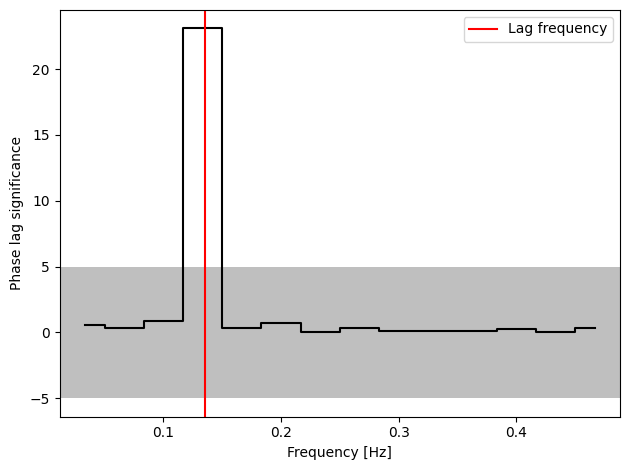

In [28]:
fig, ax = plt.subplots(tight_layout=True)

ax.step(
    avg_cs.freq,
    np.abs(plags / plags_err),
    where='mid',
    c='black',
)

ax.fill_between(
    ax.set_xlim(),
    -5, 5,
    color='grey',
    alpha=.5,
    edgecolor='none',
)

ax.axvline(
    0.135,
    c='red',
    label='Lag frequency'
    )

ax.legend()

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Phase lag significance')

plt.show()

Now we can see that the phase lag is significant to $\gg 5 \sigma$, as we would hope.

That concludes the timing methods tutorial for `opticam`! The timing methods of `Analyzer` demonstrated here are intended as "quick-look" analyses, while more complete analyses are made easy thanks to `stingray`. Note, however, that special care is needed to get the most out of `stingray`.